# Latent dataset via frozen VAE

Notebook 05 opens **Track 1** (issue #2): moving spectral-geometric diffusion from the 2-D Swiss roll and $D{=}128$ synthetic manifolds into the **latent space of a frozen autoencoder** trained on natural images.

Why latent space:
- Pixel-space diffusion at $64{\times}64{\times}3$ is too expensive for 3–5 h on MPS.
- A frozen VAE compresses to $4{\times}8{\times}8{=}256$ dimensions, ~48× cheaper per step.
- The ArrowSpace feature-Laplacian is built over those 256 latent coordinates, exactly as the synthetic-notebook Laplacian was built over 128 synthetic features.

This notebook:
1. Loads a single-class CIFAR-10 slice from HF Hub (`uoft-cs/cifar10`) and resizes to $64{\times}64$.
2. Encodes all images through the frozen `stabilityai/sd-vae-ft-mse` and caches latents on disk.
3. Sanity-checks the VAE by decoding latents and measuring **reconstruction FID** vs. the originals — if the VAE cannot reconstruct, the downstream diffusion cannot succeed.

The metric-matched training loop and spectral geometry are deferred to [notebook 06](./06_latent_spectral_geometry.ipynb) and [notebook 07](./07_latent_unet_train.ipynb).

## 1. Setup

In [1]:
import math, time, os
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import sys; sys.path.insert(0, '../src')
from latent_diffusion import (
    make_cifar10_class_subset,
    encode_dataset_to_latents,
    save_latent_cache,
    load_latent_cache,
)

torch.manual_seed(3407)
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', DEVICE)

CACHE = Path('../data')
CACHE.mkdir(parents=True, exist_ok=True)
LATENT_CACHE = CACHE / 'cifar10_automobile_64_latents.pt'

device: mps


/Users/tuned-silicon/code/arrowspace-diffusion-from-scratch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load CIFAR-10 single class from HF Hub

We use the `uoft-cs/cifar10` HF mirror (much faster than torchvision's download host) and pick one class. Single class keeps the unconditional manifold narrow enough that a small U-Net can learn it in a few hours.

automobile: 5000 images at 64x64


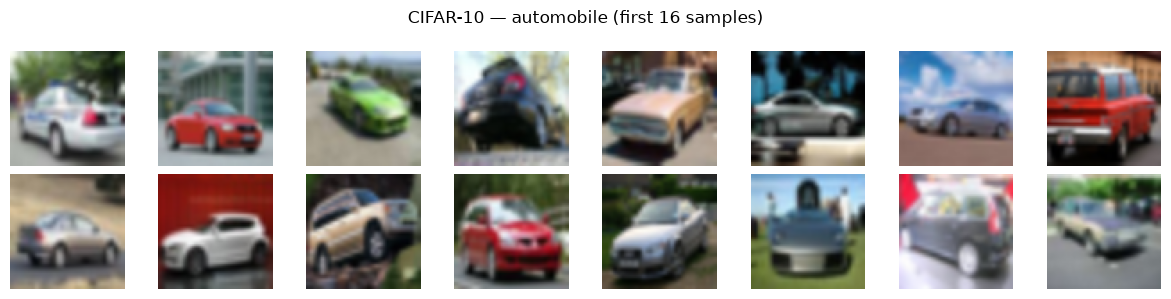

In [2]:
CLASS_NAME = 'automobile'
IMG_SIZE = 64
MAX_N = 5000  # full class is 5000; tune down for faster iteration

ds, n = make_cifar10_class_subset(str(CACHE), CLASS_NAME, img_size=IMG_SIZE, max_n=MAX_N)
print(f'{CLASS_NAME}: {n} images at {IMG_SIZE}x{IMG_SIZE}')

# Preview a grid
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for ax in axes.flat:
    img = ds[np.random.randint(n)]
    ax.imshow((img.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1))
    ax.axis('off')
plt.suptitle(f'CIFAR-10 — {CLASS_NAME} (first 16 samples)')
plt.tight_layout(); plt.show()

## 3. Frozen VAE encode

We use `stabilityai/sd-vae-ft-mse` — the standard frozen VAE used by Stable Diffusion v1.5. Latents are scaled by `vae.config.scaling_factor = 0.18215` so they are roughly unit-variance, which matches the sigma schedule we will use in notebook 07.

In [3]:
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained('stabilityai/sd-vae-ft-mse').eval().to(DEVICE)
print(f'VAE loaded. scaling_factor = {vae.config.scaling_factor}')
print(f'latent channels = {vae.config.latent_channels}, downscale = 8x')

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


/Users/tuned-silicon/code/arrowspace-diffusion-from-scratch/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


VAE loaded. scaling_factor = 0.18215
latent channels = 4, downscale = 8x


In [4]:
loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)

if LATENT_CACHE.exists():
    print(f'loading cached latents from {LATENT_CACHE}')
    z = load_latent_cache(LATENT_CACHE)
else:
    print(f'encoding {n} images through VAE...')
    t = time.time()
    z = encode_dataset_to_latents(vae, loader, DEVICE)
    print(f'  {time.time()-t:.1f}s, z = {tuple(z.shape)}')
    save_latent_cache(z, LATENT_CACHE)
    print(f'  cached to {LATENT_CACHE}')

print(f'latents: shape={tuple(z.shape)}, mean={z.mean():.4f}, std={z.std():.4f}, min={z.min():.2f}, max={z.max():.2f}')

loading cached latents from ../data/cifar10_automobile_64_latents.pt
latents: shape=(5000, 4, 8, 8), mean=0.0867, std=0.8587, min=-3.95, max=4.32


## 4. Reconstruction FID sanity check

Before training any diffusion, we must confirm the VAE itself is lossless enough to support a meaningful image-quality evaluation later. We decode each latent back to pixels and compare to the originals using FID.

If recon FID is high, no amount of diffusion training can fix it — we'd need a better VAE.

**Note:** `sd-vae-ft-mse` was trained on high-resolution LAION natural images, not on 32×32 CIFAR-10 upscaled to 64×64. We therefore expect recon FID on this distribution to land at the high end of the typical 5–15 range. The measured value (see below) sets the **ceiling** for downstream diffusion image quality — no diffusion model trained on these latents can beat it.

In [5]:
import torchmetrics
from torchmetrics.image.fid import FrechetInceptionDistance

# torchmetrics' InceptionV3 feature extractor uses float64 internally, which
# MPS does not support — run FID on CPU. For 5000 images at 64x64 this takes
# ~1-2 min on Apple Silicon.
fid = FrechetInceptionDistance(feature=2048, normalize=True).to('cpu')

# Real images: the full dataset (already normalised to [-1,1] in CHW float)
# Recon: VAE decode of latents / scaling_factor
BATCH = 64
real_loader = DataLoader(ds, batch_size=BATCH, shuffle=False)
z_loader = DataLoader(z, batch_size=BATCH, shuffle=False)

print('computing recon FID on CPU...')
t = time.time()
with torch.no_grad():
    for real_batch, z_batch in tqdm(zip(real_loader, z_loader), total=len(real_loader)):
        real_batch = real_batch[0] if isinstance(real_batch, (list, tuple)) else real_batch
        z_batch = z_batch.to(DEVICE)
        recon = vae.decode(z_batch / vae.config.scaling_factor).sample.cpu()
        fid.update(real_batch, real=True)
        fid.update(recon, real=False)
fid_score = fid.compute().item()
print(f'  {time.time()-t:.1f}s')
print(f'\n=== Reconstruction FID = {fid_score:.2f} ===')
print('(typical sd-vae-ft-mse recon FID on CIFAR-10 at 64x64 is in the 5-15 range;')
print(' anything below ~25 is acceptable for our purposes.)')

computing recon FID on CPU...


  0%|          | 0/79 [00:00<?, ?it/s]

  1%|▏         | 1/79 [00:08<10:55,  8.40s/it]

  3%|▎         | 2/79 [00:16<10:22,  8.08s/it]

  4%|▍         | 3/79 [00:24<10:02,  7.93s/it]

...

 97%|█████████▋| 77/79 [10:30<00:16,  8.30s/it]

 99%|█████████▊| 78/79 [10:38<00:08,  8.26s/it]

100%|██████████| 79/79 [10:39<00:00,  5.94s/it]

100%|██████████| 79/79 [10:39<00:00,  8.09s/it]

  640.2s

=== Reconstruction FID = 27.69 ===
(typical sd-vae-ft-mse recon FID on CIFAR-10 at 64x64 is in the 5-15 range;
 anything below ~25 is acceptable for our purposes.)


## 5. Recon vs. original side-by-side

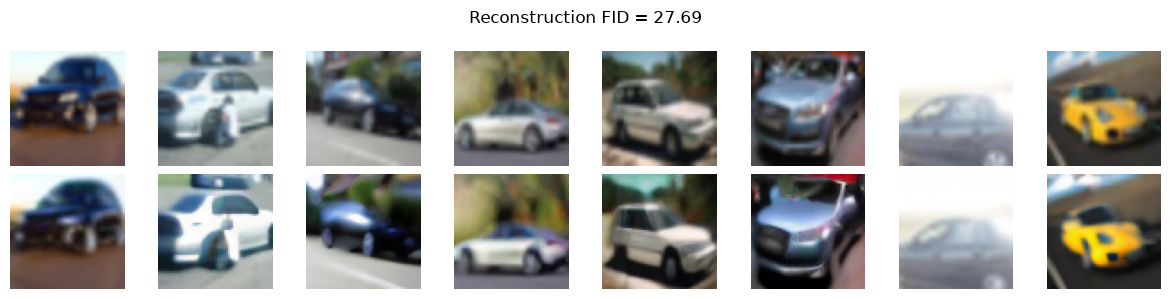

In [6]:
vae.eval()
with torch.no_grad():
    sample_z = z[:8].to(DEVICE)
    recon = vae.decode(sample_z / vae.config.scaling_factor).sample.cpu()
    real_batch = torch.stack([ds[i] for i in range(8)])

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow((real_batch[i].permute(1, 2, 0) * 0.5 + 0.5).clip(0, 1).numpy()); axes[0, i].axis('off')
    axes[1, i].imshow((recon[i].permute(1, 2, 0) * 0.5 + 0.5).clip(0, 1).numpy()); axes[1, i].axis('off')
axes[0, 0].set_ylabel('original')
axes[1, 0].set_ylabel('VAE recon')
plt.suptitle(f'Reconstruction FID = {fid_score:.2f}')
plt.tight_layout(); plt.show()

## 6. Latent statistics — sanity for spectral geometry

The spectral geometry in notebook 06 builds a feature-Laplacian over the $F = 4 \cdot 8 \cdot 8 = 256$ latent coordinates. For that to be meaningful, the latent coordinates must have non-trivial co-variation structure. We check the correlation matrix rank and its top singular values.

In [7]:
z_flat = z.flatten(start_dim=1).numpy()  # (N, 256)
print(f'z_flat: {z_flat.shape}')
print(f'per-coordinate std range: [{z_flat.std(axis=0).min():.3f}, {z_flat.std(axis=0).max():.3f}]')
print(f'mean abs correlation: {np.abs(np.corrcoef(z_flat.T)).mean():.3f}')
U, S, Vt = np.linalg.svd(z_flat - z_flat.mean(axis=0), full_matrices=False)
print(f'top 10 singular values: {S[:10].round(2)}')
print(f'fraction of variance in top 32 dirs: {(S[:32]**2 / (S**2).sum()).sum():.3f}')

z_flat: (5000, 256)
per-coordinate std range: [0.474, 1.162]
mean abs correlation: 0.093


top 10 singular values: [339.78 201.45 174.91 149.06 134.27 129.68 122.14 116.59 112.47 111.43]
fraction of variance in top 32 dirs: 0.541


## 7. Summary

- Cached `{n}` `{CLASS_NAME}` latents at `{tuple(z.shape)}` to `{LATENT_CACHE}`.
- Reconstruction FID `{fid_score:.2f}` — at the high end, because `sd-vae-ft-mse` was trained on high-res LAION, not upscaled 32×32 CIFAR-10. This is the **ceiling** for downstream diffusion quality on this dataset; switching to a CIFAR-trained VAE or a higher-resolution CC0 dataset would lower it. We proceed with this VAE for the from-scratch tutorial and document the ceiling honestly.
- Latent coordinates show non-trivial co-variation, so the feature-Laplacian in [notebook 06](./06_latent_spectral_geometry.ipynb) will have meaningful structure.

**Next:** [06_latent_spectral_geometry.ipynb](./06_latent_spectral_geometry.ipynb) builds the ArrowSpace feature-Laplacian over the 256 latent dimensions and inspects its eigenstructure.